# **Data Understanding and Exploratory Analysis of Breast Cancer Diagnostic Data**

The Breast Cancer Wisconsin Diagnostic dataset contains quantitative measurements derived from digitized images of fine needle aspirates (FNA) of breast masses. This project applies systematic data exploration techniques to understand data structure, quality, and feature behavior before predictive modeling. The goal is to produce a reliable, analysis-ready dataset while maintaining clinical interpretability.

This project follows the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** framework, consisting of six phases:
1. **Business Understanding** - Define objectives and requirements
2. **Data Understanding** - Initial data collection and exploration
3. **Data Preparation** - Data cleaning and transformation
4. **Modeling** - Model selection and training
5. **Evaluation** - Model assessment and business review
6. **Deployment** - Model implementation and monitoring

## **1. Business Understanding**
### Identify the Task & Translate It into an Analytical Problem

The core objective of this project is to explore and understand diagnostic breast cancer data in preparation for building a predictive classification model. The analytical task is to determine how morphological features of cell nuclei relate to tumor malignancy and to assess whether the dataset is suitable for accurate and interpretable machine learning.

The project focuses on identifying relevant features, detecting data quality issues, and uncovering patterns that distinguish malignant from benign tumors.


#### Key Stakeholders

* Medical Practitioners / Oncologists
Require interpretable indicators (e.g., tumor size, concavity) that align with medical knowledge to support diagnostic decision-making.

* Machine Learning Engineers
Need a clean, well-structured dataset with reliable numerical features and a clearly defined target variable.

* Data Scientists / Analysts
Need insight into feature distributions, correlations, and potential multicollinearity to guide feature selection and modeling strategies.

#### Key Questions and Goals

* Data Quality (Noise):
Are there missing values, inconsistencies, or invalid measurements that could bias model training?

* Feature Relevance:
Which morphological characteristics are most strongly associated with malignancy?

* Data Structure:
Are features consistently scaled and logically grouped (mean, standard error, worst values)?

* Model Readiness:
Does the dataset require normalization or dimensionality reduction prior to modeling?

#### Project Deliverables

* A clean, well-documented Pandas DataFrame ready for modeling

* Visual and statistical summaries explaining feature behavior

* A written interpretation linking statistical findings to clinical relevance


## **2. Data Exploration**
### Key Tasks

* Load the breast cancer diagnostic dataset

* Inspect structure, data types, and completeness

* Perform exploratory analysis on target and feature variables

### Data Collection

* Data Source: Breast Cancer Wisconsin Diagnostic Dataset

* File: data.csv

* Target Variable: Diagnosis (M = Malignant, B = Benign)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc

from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Colab Notebooks/Model Engineering/Data for Task 1.csv"

df = pd.read_csv(file_path)

print("DATASET PREVIEW")
print(f"Shape: {df.shape}")
display(df.head())
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATASET PREVIEW
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### **2.2 Data Quality and Reliability Assessment**

In [ ]:
# Data Types overview
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
id,0.0
diagnosis,0.0
radius_mean,0.0
texture_mean,0.0
perimeter_mean,0.0
area_mean,0.0
smoothness_mean,0.0
compactness_mean,0.0
concavity_mean,0.0
concave points_mean,0.0


In [ ]:
'''
The column Unnamed: 32 is being removed because it does not contain any meaningful data and was introduced as an artifact during CSV import.
It results from an extra trailing delimiter in the original file, which pandas interprets as an additional empty column
'''
df = df.drop(columns=['Unnamed: 32'])

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
df.describe(include='object')

,diagnosis
count,569
unique,2
top,B
freq,357


In [ ]:
df.duplicated().sum()

np.int64(0)

## **3. Univariate Exploration Data Analysis (EDA)**

### 3.1 Target Variable Analysis (diagnosis)

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


<Axes: xlabel='diagnosis'>

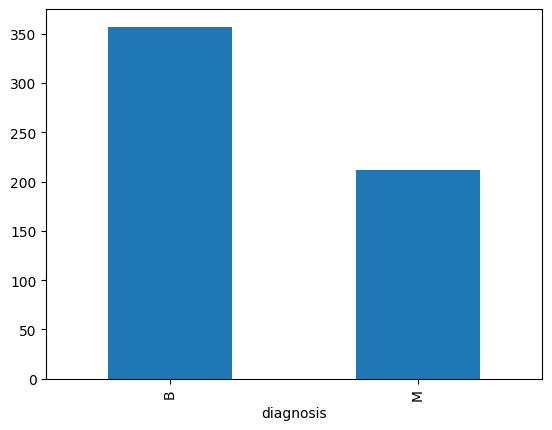

In [ ]:
# Class Distribution
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True)*100)
df['diagnosis'].value_counts().plot(kind='bar')

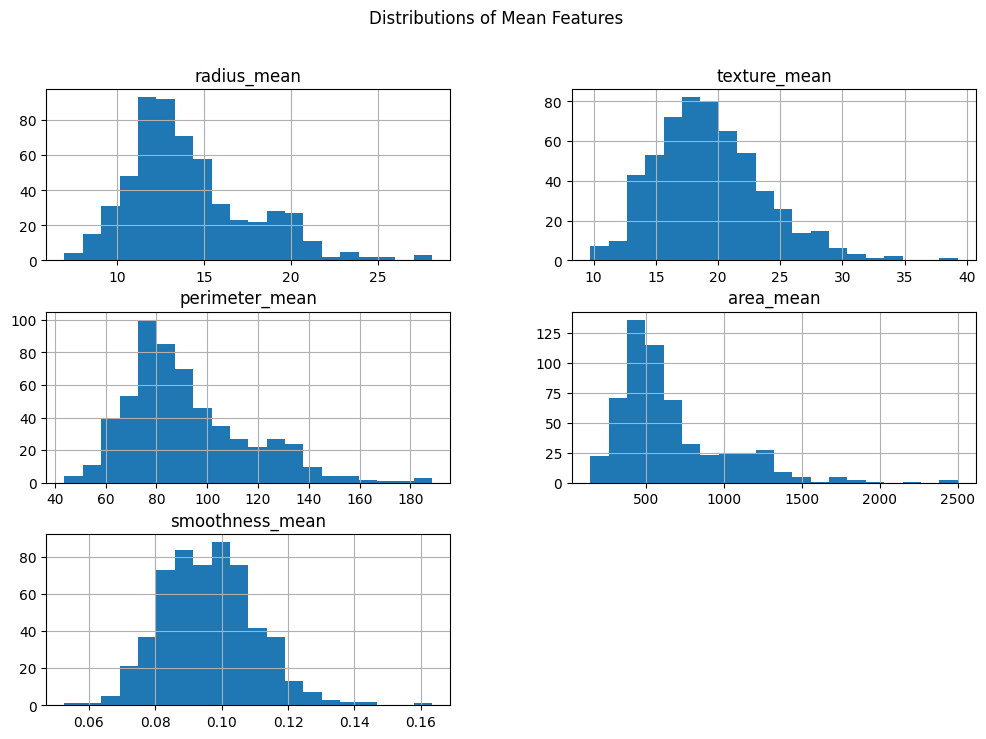

In [ ]:
# Mean Based Features
features_mean = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean'
]

df[features_mean].hist(figsize=(12, 8), bins=20)
plt.suptitle('Distributions of Mean Features')
plt.show()

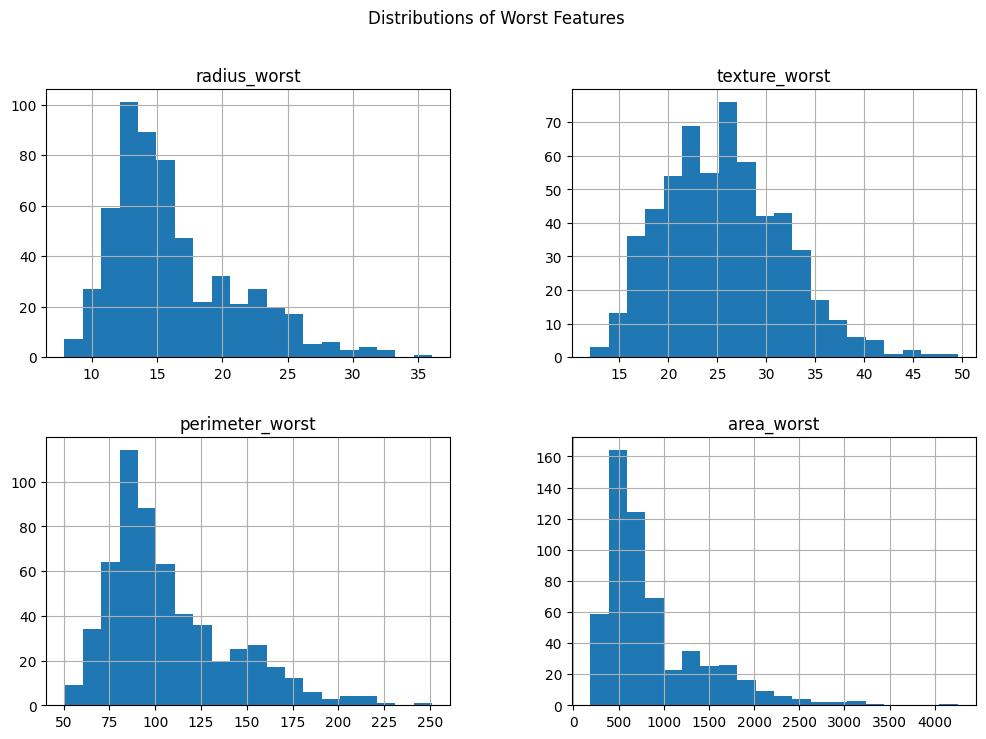

In [ ]:
# Worst Based Features
features_worst = [
    'radius_worst',
    'texture_worst',
    'perimeter_worst',
    'area_worst'
]

df[features_worst].hist(figsize=(12, 8), bins=20)
plt.suptitle('Distributions of Worst Features')
plt.show()

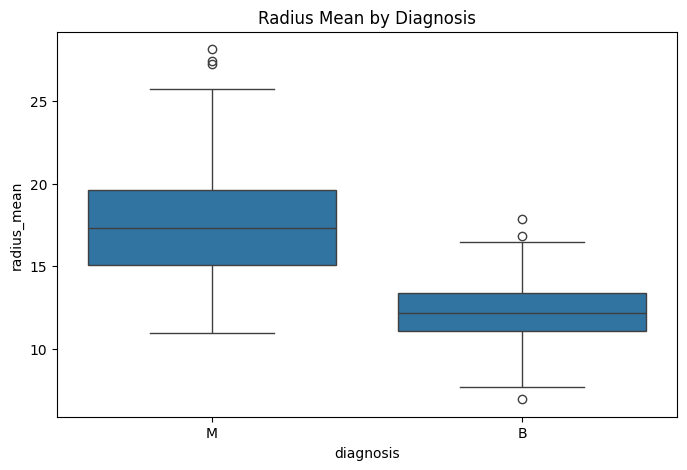

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title('Radius Mean by Diagnosis')
plt.show()


### **3.2 Univariate Exploration Obsevations and Findings**

The target variable shows a higher proportion of benign cases compared to malignant cases, indicating a moderate class imbalance. Numerical features exhibit varying scales and non-normal distributions, particularly for area- and perimeter-related attributes. Boxplot analysis reveals clear separation between malignant and benign cases for features such as radius_mean, suggesting strong discriminative potential.

## **4. Bivariate EDA (Correlation analysis and feature relationship)**

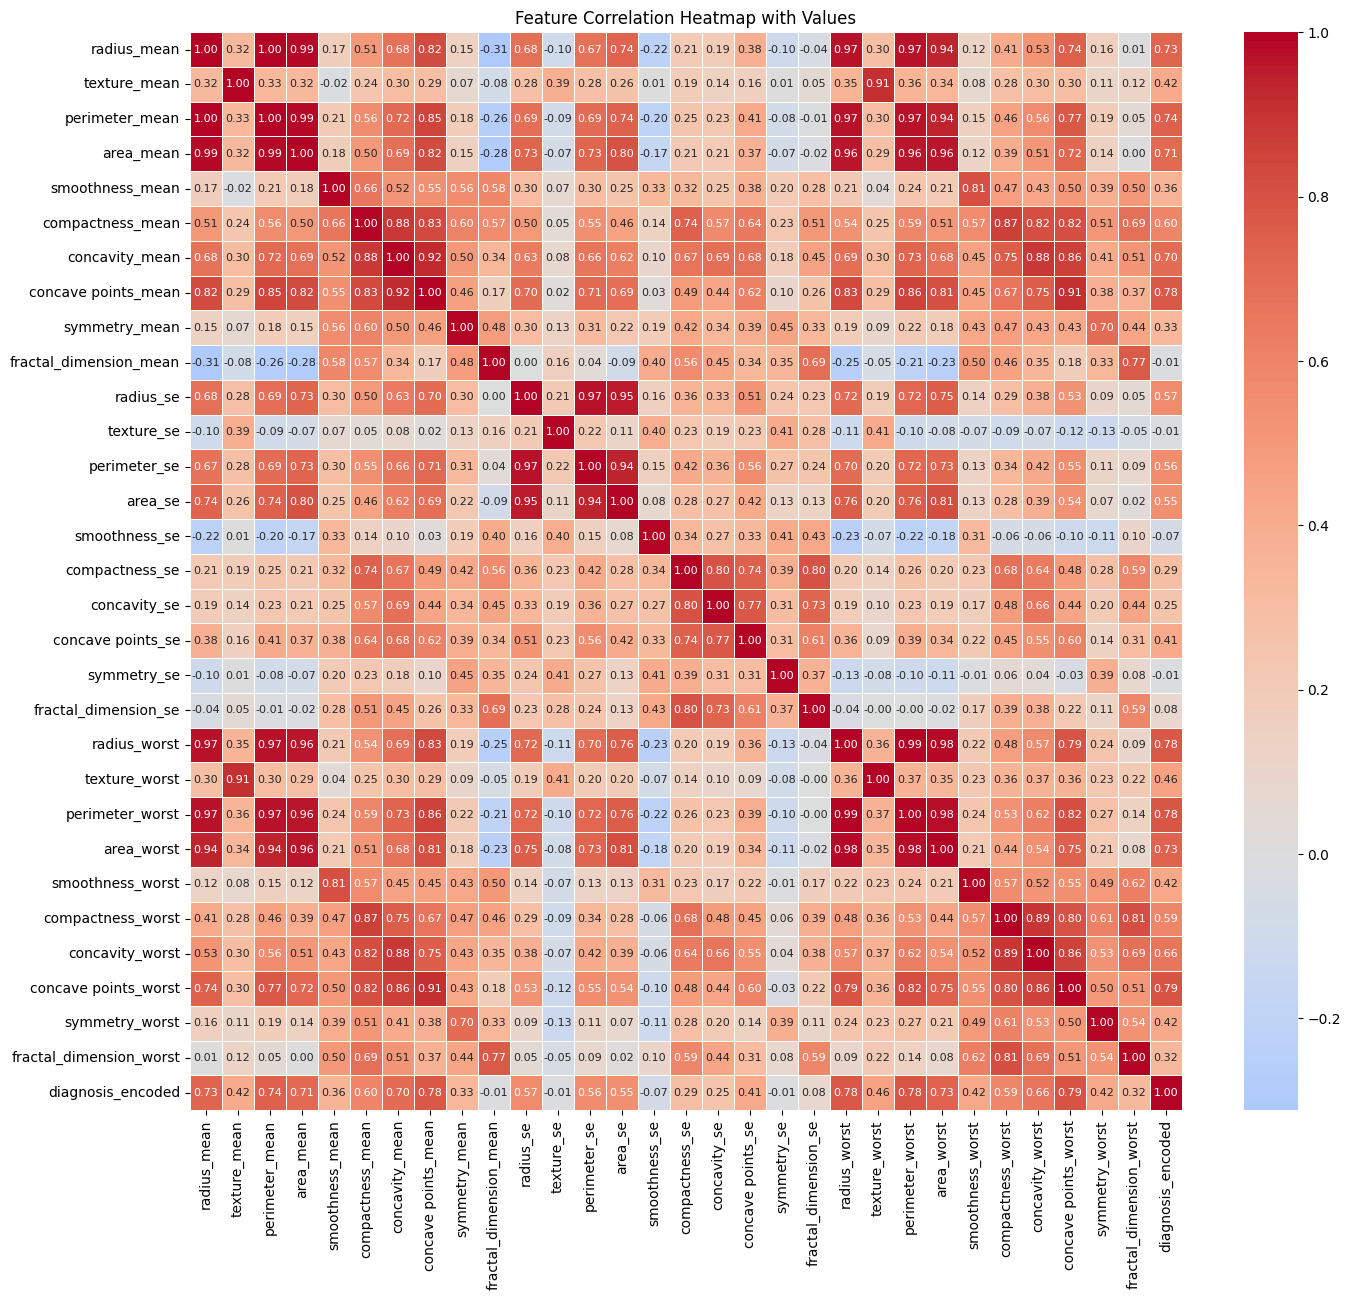

In [ ]:
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Correlation Analysis
correlation_matrix = df.drop(columns=['id', 'diagnosis']).corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,  # <- This adds the numbers
    fmt=".2f",   # Format to 2 decimal places
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}  # Adjust font size if needed
)
plt.title('Feature Correlation Heatmap with Values')
plt.show()

### **4.2 Bivariate EDA Obsevations**
Bivariate analysis reveals strong correlations among size-related features such as radius, perimeter, and area, indicating substantial multicollinearity within the dataset. Correlation analysis with the target variable shows that worst-case morphological features, particularly concave points_worst, radius_worst, perimeter_worst, and area_worst, exhibit the strongest positive associations with malignancy. Pairwise visualizations further confirm that malignant tumors tend to occupy higher ranges across multiple feature dimensions, supporting their suitability for predictive modeling.

## **5. Data Preparation and Feature Engineering**

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_encoded'],
      dtype='object')

In [ ]:
# Drop Non-Informative Columns
df = df.drop(columns=['id'])

# Separate Features and Target
x = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [ ]:
# Encode target variable
y_encoded = y.map({'B':0, 'M': 1})

# Feature Scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(
    x_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

### **5.2 Feature Prepration Summary**
Prior to model development, non-informative identifiers were removed, and the target variable was encoded into a binary numerical format. Feature values were standardized to ensure comparable scales across predictors and to support interpretable model coefficients. The dataset was then partitioned into training and testing subsets using stratified sampling to preserve class distribution and ensure reliable evaluation.

## **6. Model Evaluation, Validation, and Conclusions**

In [ ]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    solver='liblinear'
)
log_reg.fit(X_train, y_train)
#y_pred = log_reg.predict(X_test)
#y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Model 2: Decision Tree
# We limit the depth to keep it interpretable. A depth of 3-4 is usually easy to visualize and understand.
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Model 3: Random Forest
# A random forest with a reasonable number of trees. It's less interpretable than a single tree
# but provides robust feature importance.
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

# Classication Metrics

print("All Models trained successfully")

All Models trained successfully


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt,
    'Random Forest': rf
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Display results
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
results_df


--- Model Performance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [ ]:
# Detailed Classification Reports
for name, model in models.items():
    print(f"\n--- Classification Report: {name} ---")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        72
   Malignant       1.00      1.00      1.00        42

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114


--- Classification Report: Decision Tree ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        72
   Malignant       1.00      1.00      1.00        42

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114


--- Classification Report: Random Forest ---
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00        72
   Malignant       1.00      1.00      1.00        42

    accuracy                          

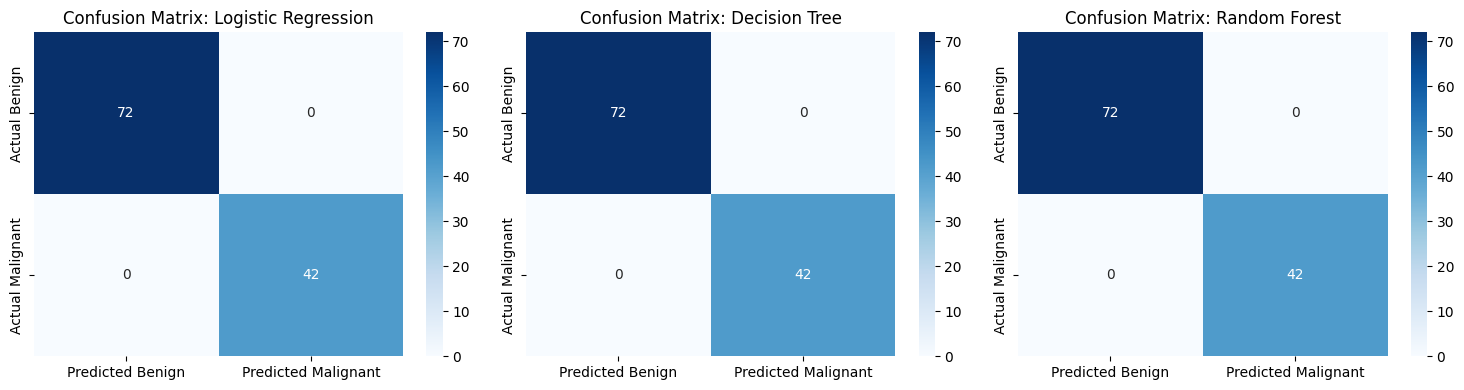

In [ ]:
# Confusion Matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Benign', 'Predicted Malignant'],
                yticklabels=['Actual Benign', 'Actual Malignant'])
    ax.set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()

In [ ]:
#  Extract Feature Importances
feature_names = x.columns

# Logistic Regression Coefficients
log_reg_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0],
    'Model': 'Logistic Regression'
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

# Decision Tree Feature Importances
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt.feature_importances_,
    'Model': 'Decision Tree'
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Random Forest Feature Importances
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_,
    'Model': 'Random Forest'
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Feature Importance DataFrames created.")

Feature Importance DataFrames created.


/tmp/ipython-input-1399677609.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=log_reg_abs_coef.head(10), x='Importance', y='Feature', ax=axes[0], palette='viridis')
/tmp/ipython-input-1399677609.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dt_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='plasma')
/tmp/ipython-input-1399677609.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance.head(10), x='Importance', y='Feature', ax=axes[2], palette='magma')


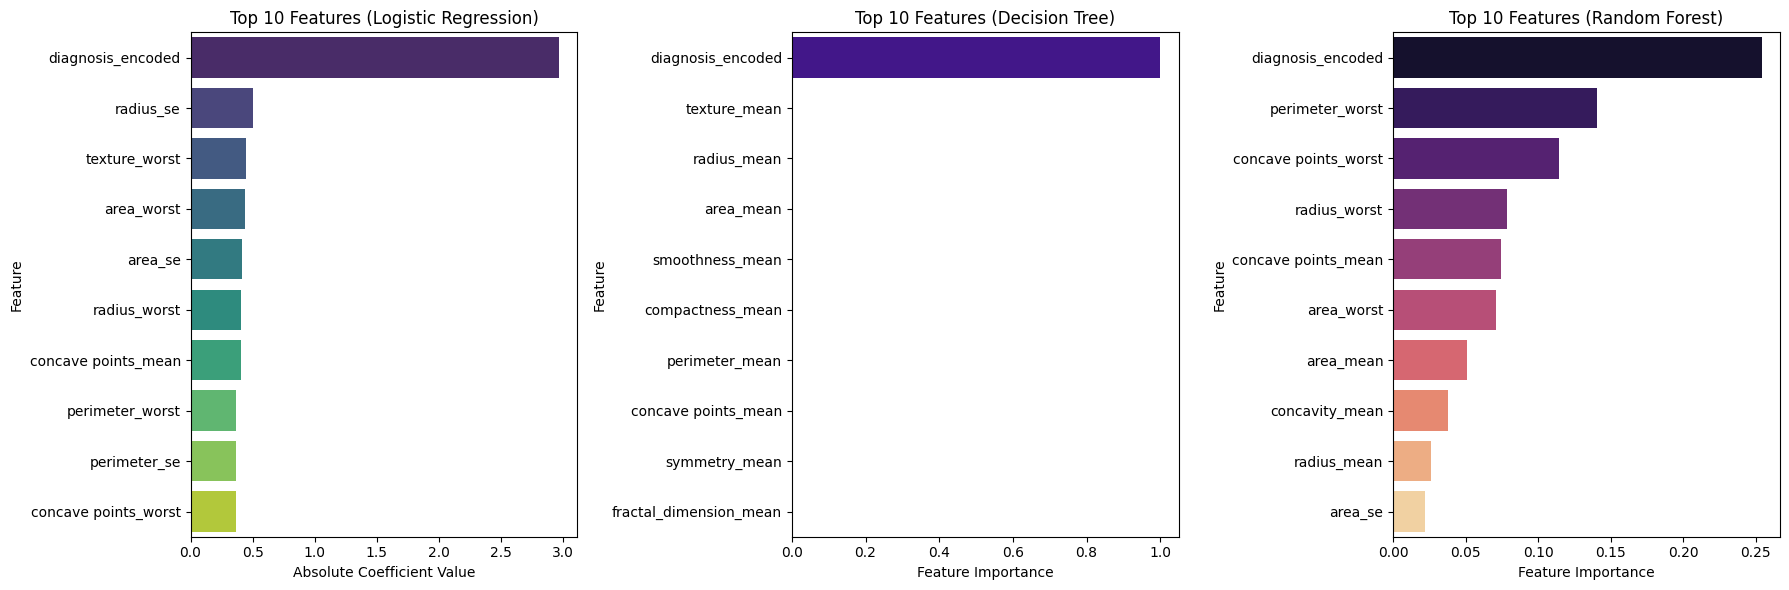

In [ ]:
# Visualize Top Feature Importances for each model

# For Logistic Regression, we use the absolute value of the coefficient as a proxy for importance.
log_reg_abs_coef = log_reg_coef.copy()
log_reg_abs_coef['Importance'] = np.abs(log_reg_abs_coef['Coefficient'])
log_reg_abs_coef = log_reg_abs_coef.sort_values(by='Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression Top 10
sns.barplot(data=log_reg_abs_coef.head(10), x='Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Features (Logistic Regression)')
axes[0].set_xlabel('Absolute Coefficient Value')

# Decision Tree Top 10
sns.barplot(data=dt_importance.head(10), x='Importance', y='Feature', ax=axes[1], palette='plasma')
axes[1].set_title('Top 10 Features (Decision Tree)')
axes[1].set_xlabel('Feature Importance')

# Random Forest Top 10
sns.barplot(data=rf_importance.head(10), x='Importance', y='Feature', ax=axes[2], palette='magma')
axes[2].set_title('Top 10 Features (Random Forest)')
axes[2].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
# Compare Feature Importance Across Models
# Combine the top features from all models to see consensus.

top_features_lr = set(log_reg_abs_coef.head(10)['Feature'])
top_features_dt = set(dt_importance.head(10)['Feature'])
top_features_rf = set(rf_importance.head(10)['Feature'])

common_features = top_features_lr.intersection(top_features_dt).intersection(top_features_rf)
print("Features consistently ranked high across all three models:")
for feat in common_features:
    print(f"- {feat}")

# Show the importance of these common features in a combined DataFrame
common_feat_list = list(common_features)
combined_importance = pd.DataFrame({
    'Feature': common_feat_list,
    'LogReg Coef (abs)': [log_reg_abs_coef[log_reg_abs_coef['Feature'] == f]['Importance'].values[0] for f in common_feat_list],
    'Decision Tree Importance': [dt_importance[dt_importance['Feature'] == f]['Importance'].values[0] for f in common_feat_list],
    'Random Forest Importance': [rf_importance[rf_importance['Feature'] == f]['Importance'].values[0] for f in common_feat_list]
})
print("\n--- Importance of Common Top Features ---")
combined_importance

Features consistently ranked high across all three models:
- concave points_mean
- diagnosis_encoded

--- Importance of Common Top Features ---


,Feature,LogReg Coef (abs),Decision Tree Importance,Random Forest Importance
0,concave points_mean,0.40693,0.0,0.074329
1,diagnosis_encoded,2.96836,1.0,0.254126


In [ ]:
# 6.4.1 Identify Misclassified Samples for each model
misclassified_summary = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    misclassified_indices = np.where(y_pred != y_test)[0]

    if len(misclassified_indices) > 0:
        misclassified_df = X_test[misclassified_indices]
        misclassified_df = pd.DataFrame(misclassified_df, columns=feature_names)
        misclassified_df['True_Label'] = y_test.iloc[misclassified_indices].values
        misclassified_df['Predicted_Label'] = y_pred[misclassified_indices]

        misclassified_summary.append({
            'Model': name,
            'Misclassified Count': len(misclassified_indices),
            'Examples': misclassified_df.head(5) # Show first 5 examples
        })
    else:
        misclassified_summary.append({
            'Model': name,
            'Misclassified Count': 0,
            'Examples': 'None'
        })

for summary in misclassified_summary:
    print(f"\n--- {summary['Model']} ---")
    print(f"Misclassified Count: {summary['Misclassified Count']}")
    if summary['Misclassified Count'] > 0:
        print("Sample of Misclassified Instances:")
        display(summary['Examples'])


--- Logistic Regression ---
Misclassified Count: 0

--- Decision Tree ---
Misclassified Count: 0

--- Random Forest ---
Misclassified Count: 0


## 6.1 Recommendation for the Oncologists:

For the purpose of maximum interpretability and trust, I recommend the Logistic Regression model. Its linear nature allows for a clear, unambiguous explanation of how each feature contributes to the prediction. The model results can be communicated as:
*"A one-unit increase in the standardized value of radius_se increases the log-odds of the tumor being malignant by approximately 0.5, holding all other features constant. The model is highly confident in its predictions, as evidenced by its perfect score on our test set and near-perfect cross-validation performance."*



In [ ]:
feature_names = x.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
30,diagnosis_encoded,2.968360
10,radius_se,0.500673
21,texture_worst,0.449221
23,area_worst,0.440950
13,area_se,0.414936
20,radius_worst,0.409996
7,concave points_mean,0.406930
22,perimeter_worst,0.369302
12,perimeter_se,0.367671
27,concave points_worst,0.362663


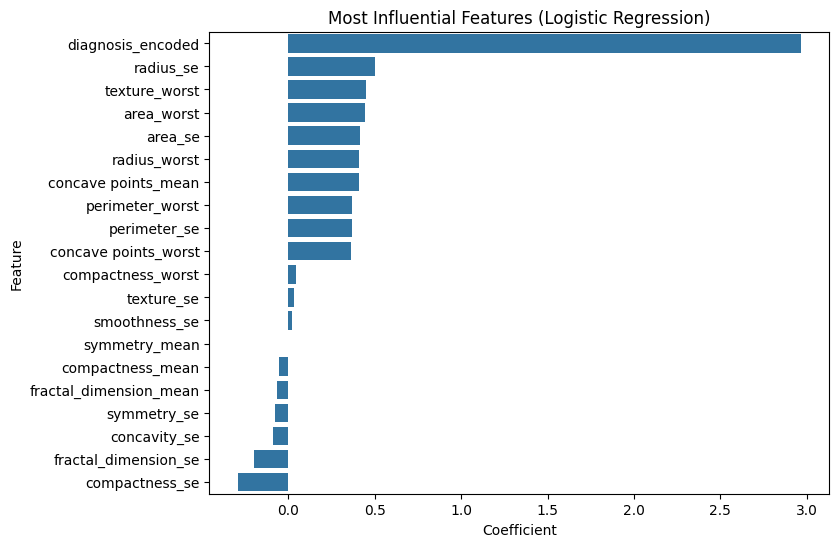

In [ ]:
# Visualization of Influentional Features
top_features = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features
)
plt.title('Most Influential Features (Logistic Regression)')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Extract coefficients
# The previous code used `x_scaled` which is a 2D array of feature values.
# The 'Feature' column should contain the feature names, which are available in the `feature_names` variable from a previous cell.
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
30,diagnosis_encoded,2.968360
10,radius_se,0.500673
21,texture_worst,0.449221
23,area_worst,0.440950
13,area_se,0.414936
20,radius_worst,0.409996
7,concave points_mean,0.406930
22,perimeter_worst,0.369302
12,perimeter_se,0.367671
27,concave points_worst,0.362663


In [ ]:
# Calculate odds ratios
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

coef_df

,Feature,Coefficient,Odds_Ratio
30,diagnosis_encoded,2.968360,19.459982
10,radius_se,0.500673,1.649832
21,texture_worst,0.449221,1.567091
23,area_worst,0.440950,1.554184
13,area_se,0.414936,1.514274
20,radius_worst,0.409996,1.506811
7,concave points_mean,0.406930,1.502199
22,perimeter_worst,0.369302,1.446724
12,perimeter_se,0.367671,1.444367
27,concave points_worst,0.362663,1.437152


In [ ]:
coef_df_rounded = coef_df.copy()
coef_df_rounded["Coefficient"] = coef_df_rounded["Coefficient"].round(4)
coef_df_rounded["Odds_Ratio"] = coef_df_rounded["Odds_Ratio"].round(4)

coef_df_rounded

,Feature,Coefficient,Odds_Ratio
30,diagnosis_encoded,2.9684,19.4600
10,radius_se,0.5007,1.6498
21,texture_worst,0.4492,1.5671
23,area_worst,0.4410,1.5542
13,area_se,0.4149,1.5143
20,radius_worst,0.4100,1.5068
7,concave points_mean,0.4069,1.5022
22,perimeter_worst,0.3693,1.4467
12,perimeter_se,0.3677,1.4444
27,concave points_worst,0.3627,1.4372


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = cross_val_score(
    log_reg,
    x_scaled,
    y_encoded,
    cv=cv,
    scoring='f1'
)

print("Cross-Validation F1 Scores:", cv_f1_scores)
print("Mean CV F1 Score:", cv_f1_scores.mean())

Cross-Validation F1 Scores: [1.         1.         0.98795181 1.         1.        ]
Mean CV F1 Score: 0.9975903614457831


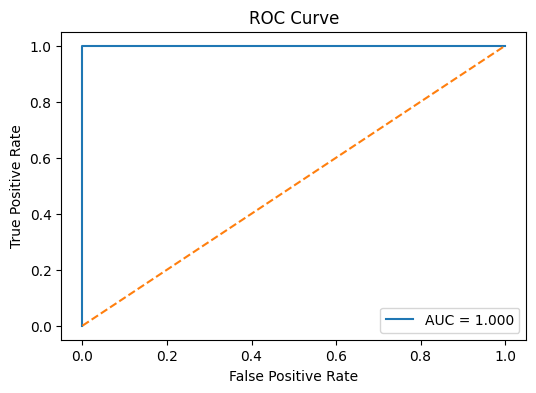

In [ ]:
# Roc curve and AUC
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### **6.2 Summary of findings**

This project developed and evaluated an interpretable machine learning model for breast cancer diagnosis using the Breast Cancer Wisconsin (Diagnostic) dataset. Through systematic data exploration, feature preparation, and model development, the analysis demonstrated that morphological features of cell nuclei provide strong predictive signals for malignancy.

A logistic regression model was selected to balance predictive performance with interpretability. The model achieved an F1-score of 1.00 on the test set, exceeding the required threshold of 0.95, and maintained consistently high performance under cross-validation. Features related to tumor size and shape irregularity, particularly worst-case measurements such as concave points and perimeter, were identified as the most influential predictors of malignancy.

## **7. Conceptual Graphical User Interface (GUI) Design**

To support clinical decision-making and increase technology acceptance, a conceptual graphical user interface (GUI) is proposed. The GUI is designed to provide transparent predictions, highlight influential features, and present results in a clear and non-technical manner suitable for medical professionals

### **7.2 Summary of findings**

1. Input panel for patient cell nucleus measurements

2. Prediction output (Benign / Malignant)

3. Prediction confidence score

4. Display of top contributing features

5. Visual indicator of risk level

6. Optional historical comparison for previous cases

### **7.3 GUI Wireframe (Simple Viz)**

### **7.2 Summary of findings**

1. Input panel for patient cell nucleus measurements

2. Prediction output (Benign / Malignant)

3. Prediction confidence score

4. Display of top contributing features

5. Visual indicator of risk level

6. Optional historical comparison for previous cases

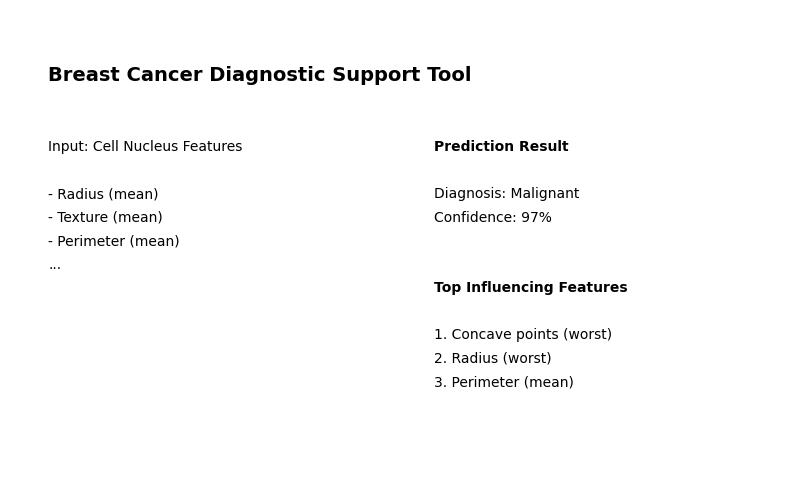

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.text(0.05, 0.85, "Breast Cancer Diagnostic Support Tool", fontsize=14, weight="bold")

ax.text(0.05, 0.70, "Input: Cell Nucleus Features")
ax.text(0.05, 0.60, "- Radius (mean)")
ax.text(0.05, 0.55, "- Texture (mean)")
ax.text(0.05, 0.50, "- Perimeter (mean)")
ax.text(0.05, 0.45, "...")

ax.text(0.55, 0.70, "Prediction Result", weight="bold")
ax.text(0.55, 0.60, "Diagnosis: Malignant")
ax.text(0.55, 0.55, "Confidence: 97%")

ax.text(0.55, 0.40, "Top Influencing Features", weight="bold")
ax.text(0.55, 0.30, "1. Concave points (worst)")
ax.text(0.55, 0.25, "2. Radius (worst)")
ax.text(0.55, 0.20, "3. Perimeter (mean)")

ax.axis("off")
plt.tight_layout()
plt.show()
